# RNN 用于时间序列预测
数据是首都国际机场1949~1960 这的客流量，共144个月的数据。前9年的数据（75%）作为训练集，后3年的数据（25%）作为测试集。

#### 安装所需包，若已安装则忽略

In [ ]:
# !pip install numpy -i https://pypi.tuna.tsinghua.edu.cn/simple

In [ ]:
# !pip install pandas -i https://pypi.tuna.tsinghua.edu.cn/simple

In [ ]:
# !pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple

In [ ]:
# !pip install torch -i https://pypi.tuna.tsinghua.edu.cn/simple

首先我们可以读入数据，这个数据是 10 年飞机月流量，可视化得到下面的效果。

In [1]:
import warnings
warnings.filterwarnings('ignore')  # 忽略所有警告

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_csv = pd.read_csv('./data.csv', usecols=[1])

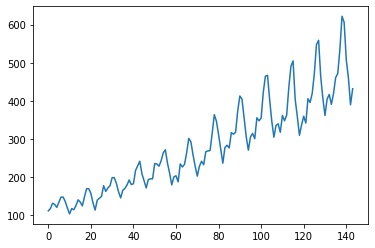

In [3]:
plt.plot(data_csv)

首先我们进行预处理，将数据中 `na` 的数据去掉，然后将数据标准化到 0 ~ 1 之间。

In [4]:
# 数据预处理
data_csv = data_csv.dropna()
dataset = data_csv.values
dataset = dataset.astype('float32')
max_value = np.max(dataset)
min_value = np.min(dataset)
scalar = max_value - min_value
dataset = list(map(lambda x: x / scalar, dataset))

接着我们进行数据集的创建，我们想通过前面几个月的流量来预测当月的流量，比如我们希望通过前6个月的流量来预测当月的流量，我们可以将前6个月的流量当做输入，当月的流量当做输出。同时我们需要将我们的数据集分为训练集和测试集，通过测试集的效果来测试模型的性能，这里我们简单的将前面几年的数据作为训练集，后面两年的数据作为测试集。

In [5]:
def create_dataset(dataset, look_back=6):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back)]
        dataX.append(a)
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

In [6]:
# 创建好输入输出
data_X, data_Y = create_dataset(dataset)

In [7]:
# 划分训练集和测试集，80% 作为训练集
train_size = int(len(data_X) * 0.8)
test_size = len(data_X) - train_size
train_X = data_X[:train_size]
train_Y = data_Y[:train_size]
test_X = data_X[train_size:]
test_Y = data_Y[train_size:]

In [8]:
train_Y.shape

(110, 1)

In [9]:
test_Y.shape

(28, 1)

最后，我们需要将数据改变一下形状，因为 RNN 读入的数据维度是 (batch_size, seq_len, input_size)，所以要重新改变一下数据的维度，这里的 seq_len 就是我们希望依据的几个月份，这里我们定的是6个月份，所以 seq_len 就是 6，而输入每个时刻只有一个值，是一维时间序列，所以 input_size 是 1.

In [10]:
import torch
from torch import nn
# 设置随机种子以确保实验可重复
seed = 20251130
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

train_X = train_X.reshape(-1, 6, 1)
train_Y = train_Y.reshape(-1, 1, 1)
test_X = test_X.reshape(-1, 6, 1)

train_x = torch.from_numpy(train_X)
train_y = torch.from_numpy(train_Y)
test_x = torch.from_numpy(test_X)

这里定义好模型，模型的第一部分是一个两层的 RNN 模型 `nn.LSTM`，每一步模型接受维度为input_size的输入数据，得到的维度为hidden_size的输出向量。输入序列长度为6，故 RNN 输出的时间步数也为6。接着通过一个线性层 `nn.Linear` 将 RNN 最后一步的的输出向量回归到流量的具体数值，之后我们需要用 `view` 来重新排列，与y对齐格式。

In [11]:
# 定义模型
class lstm_reg(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=2):
        super(lstm_reg, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True) # rnn
        self.reg = nn.Linear(hidden_size, output_size) # 回归
        
    def forward(self, x):
        x, _ = self.lstm(x) # (batch_size, seq_len, hidden_size)
        x = x[:, -1, :] # 只取 RNN 最后一个时间步的输出
        x = self.reg(x)
        x = x.view(-1, 1, 1) # 与 y 对齐格式
        return x

定义好网络结构，输入为一维时间序列，所以input_size=1，隐藏层的维度可以任意指定，这里我们选的 12

In [12]:
input_size = 1
hidden_size = 12
lr = 1e-2

net = lstm_reg(input_size, hidden_size)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

指定训练的 epoch (数据完整遍历次数)，开始训练。

In [13]:
# 开始训练
epoch = 2000
for e in range(epoch):
    # 前向传播
    out = net(train_x)
    loss = criterion(out, train_y)
    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (e + 1) % 100 == 0: # 每 100 次输出结果
        print('Epoch: {}, Loss: {:.5f}'.format(e + 1, loss.item()))

Epoch: 100, Loss: 0.00720
Epoch: 200, Loss: 0.00353
Epoch: 300, Loss: 0.00222
Epoch: 400, Loss: 0.00208
Epoch: 500, Loss: 0.00188
Epoch: 600, Loss: 0.00172
Epoch: 700, Loss: 0.00132
Epoch: 800, Loss: 0.00185
Epoch: 900, Loss: 0.00109
Epoch: 1000, Loss: 0.00100
Epoch: 1100, Loss: 0.00088
Epoch: 1200, Loss: 0.00070
Epoch: 1300, Loss: 0.00059
Epoch: 1400, Loss: 0.00045
Epoch: 1500, Loss: 0.00094
Epoch: 1600, Loss: 0.00030
Epoch: 1700, Loss: 0.00033
Epoch: 1800, Loss: 0.00024
Epoch: 1900, Loss: 0.00023
Epoch: 2000, Loss: 0.00022


训练完成之后，我们可以用训练好的模型去预测后面的结果

In [14]:
net = net.eval() # 转换成测试模式

In [15]:
data_X = data_X.reshape(-1, 6, 1)
data_X = torch.from_numpy(data_X)
pred_test = net(data_X) # 测试集的预测结果

In [16]:
# 改变输出的格式
pred_test = pred_test.view(-1).data.numpy()

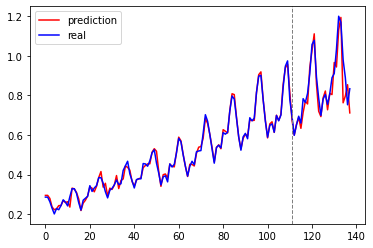

In [17]:
# 画出实际结果和预测的结果
plt.plot(pred_test, 'r', label='prediction')
plt.plot(dataset[6:], 'b', label='real')
plt.axvline(x=111, color='gray', linestyle='--', linewidth=1, label='')
plt.legend(loc='best')

这里蓝色的是真实的数据集，红色的是预测的结果，我们能够看到，使用 lstm 能够得到比较相近的结果，预测的趋势也与真实的数据集是相同的，因为其能够记忆之前的信息，而单纯的使用线性回归并不能得到较好的结果，从这个例子也说明了 RNN 对于序列有着非常好的性能。